# Analysis Without GSM8K Records

This notebook filters out all GSM8K records and analyzes only the algorithmic tasks:
- CLRS (classic algorithms)
- NPHard (NP-hard problems)
- Fine-grained (arithmetic/dynamic programming)

GSM8K is excluded because it's a different task type (math word problems) that doesn't fit the algorithmic focus.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path for imports
PROJECT_ROOT = Path("../../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.exps_performance.logger import create_big_df

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

RESULTS_DIR = Path("../results")
JSON_ERROR_THRESHOLD = 0.50  # 50% threshold

print(f"Results directory: {RESULTS_DIR.resolve()}")

Results directory: /Users/terrytong/Documents/CCG/ToolProj/src/exps_performance/results


## Load All Data

In [2]:
# Load all JSONL results
jsonl_files = sorted(RESULTS_DIR.rglob("*.jsonl"))
print(f"Found {len(jsonl_files)} JSONL files")

df_all = create_big_df(jsonl_files)
print(f"Loaded {len(df_all):,} total rows")
print(f"Models found: {df_all['model'].nunique()}")
print(f"Task kinds: {df_all['kind'].nunique()}")

Found 28 JSONL files


Loaded 46,430 total rows
Models found: 10
Task kinds: 49


## Filter Out GSM8K Records

In [3]:
# Check GSM8K presence before filtering
gsm8k_count = (df_all["kind"] == "gsm8k").sum()
print(f"GSM8K records before filtering: {gsm8k_count:,}")

# Filter out GSM8K records
df = df_all[df_all["kind"] != "gsm8k"].copy()

print(f"\n{'=' * 60}")
print("GSM8K FILTERING COMPLETE")
print(f"{'=' * 60}")
print(f"Records REMOVED (GSM8K): {gsm8k_count:,}")
print(f"Records REMAINING: {len(df):,}")
print(f"Data retained: {len(df) / len(df_all) * 100:.1f}%")

# Verify no GSM8K remains
gsm8k_remaining = (df["kind"] == "gsm8k").sum()
print(f"\nVerification - GSM8K records remaining: {gsm8k_remaining}")
assert gsm8k_remaining == 0, "ERROR: GSM8K records still present!"

GSM8K records before filtering: 4,500

GSM8K FILTERING COMPLETE
Records REMOVED (GSM8K): 4,500
Records REMAINING: 41,930
Data retained: 90.3%

Verification - GSM8K records remaining: 0


In [4]:
# Show remaining task distribution
print("\nRemaining task kinds:")
print(df["kind"].value_counts().head(20))


Remaining task kinds:
kind
sub                     1524
add                     1524
mul                     1524
lcs                     1524
rod                     1524
knap                    1524
ilp_assign              1524
segments_intersect      1504
ilp_prod                1479
spp                     1455
tsp                     1455
ksp                     1455
gcp                     1455
edp                     1455
ilp_partition           1452
naive_string_matcher    1287
tsp_d                   1200
msp                     1200
gcp_d                   1200
bsp                     1200
Name: count, dtype: int64


## Apply 50% JSON Error Filtering

In [5]:
def has_real_error(err_msg):
    """Check if err_msg indicates a REAL error."""
    if not err_msg or err_msg == "":
        return True
    err_msg = str(err_msg).lower().strip()
    return err_msg not in ["ok", "ok,ok"]


# Compute sim_err per row
df["sim_err"] = df["sim_err_msg"].apply(has_real_error)

# Compute per-model error rates
model_err_rates = (
    df.groupby("model")
    .agg(
        {
            "sim_err": "mean",
            "sim_correct": "mean",
            "nl_correct": "mean",
            "code_correct": "mean",
        }
    )
    .reset_index()
)
model_err_rates.columns = ["model", "sim_err_rate", "sim_acc", "nl_acc", "code_acc"]
model_err_rates = model_err_rates.sort_values("sim_err_rate", ascending=False)

print("Per-model simulation error rates (no GSM8K):")
print(model_err_rates.to_string(index=False))

Per-model simulation error rates (no GSM8K):
                             model  sim_err_rate  sim_acc   nl_acc  code_acc
      mistralai/ministral-14b-2512      0.215400 0.156000 0.163200  0.342800
  qwen/qwen-2.5-coder-32b-instruct      0.203207 0.115845 0.090235  0.084251
                openai/gpt-4o-mini      0.143400 0.166600 0.190800  0.352000
meta-llama/llama-3.1-405b-instruct      0.080059 0.154715 0.124754  0.139489
        anthropic/claude-haiku-4.5      0.025988 0.290274 0.243009  0.387994
           google/gemini-2.5-flash      0.001899 0.234810 0.241772  0.455696
  mistralai/mixtral-8x22b-instruct      0.001145 0.197328 0.195992  0.341412
       google/gemini-2.0-flash-001      0.000191 0.223282 0.233397  0.365267
          mistralai/codestral-2508      0.000000 0.222857 0.194762  0.407619
      mistralai/mistral-large-2411      0.000000 0.191358 0.000000  0.175154


In [6]:
# Filter models with <=50% error rate
good_models = model_err_rates[model_err_rates["sim_err_rate"] <= JSON_ERROR_THRESHOLD]["model"].tolist()
bad_models = model_err_rates[model_err_rates["sim_err_rate"] > JSON_ERROR_THRESHOLD]["model"].tolist()

print(f"Models KEPT (<=50% sim error): {len(good_models)}")
for m in good_models:
    rate = model_err_rates[model_err_rates["model"] == m]["sim_err_rate"].iloc[0]
    print(f"  INCLUDED: {m} ({rate * 100:.1f}% error)")

print(f"\nModels FILTERED OUT (>50% sim error): {len(bad_models)}")
for m in bad_models:
    rate = model_err_rates[model_err_rates["model"] == m]["sim_err_rate"].iloc[0]
    print(f"  EXCLUDED: {m} ({rate * 100:.1f}% error)")

# Apply model filter
df_filtered = df[df["model"].isin(good_models)].copy()

Models KEPT (<=50% sim error): 10
  INCLUDED: mistralai/ministral-14b-2512 (21.5% error)
  INCLUDED: qwen/qwen-2.5-coder-32b-instruct (20.3% error)
  INCLUDED: openai/gpt-4o-mini (14.3% error)
  INCLUDED: meta-llama/llama-3.1-405b-instruct (8.0% error)
  INCLUDED: anthropic/claude-haiku-4.5 (2.6% error)
  INCLUDED: google/gemini-2.5-flash (0.2% error)
  INCLUDED: mistralai/mixtral-8x22b-instruct (0.1% error)
  INCLUDED: google/gemini-2.0-flash-001 (0.0% error)
  INCLUDED: mistralai/codestral-2508 (0.0% error)
  INCLUDED: mistralai/mistral-large-2411 (0.0% error)

Models FILTERED OUT (>50% sim error): 0


## Generate Analysis Figure

Generating figure with filtered models (no GSM8K)...
[plot_v_graph_closed] Filtering to 44 task kinds


[plot_v_graph_closed] Kinds in data: ['activity_selector', 'add', 'articulation_points', 'bellman_ford', 'bfs', 'binary_search', 'bridges', 'bubble_sort', 'dag_shortest_paths', 'dfs', 'dijkstra', 'edp', 'find_maximum_subarray_kadane', 'floyd_warshall', 'gcp', 'graham_scan', 'heapsort', 'ilp_assign', 'ilp_partition', 'ilp_prod', 'insertion_sort', 'jarvis_march', 'kmp_matcher', 'knap', 'ksp', 'lcs', 'lcs_length', 'matrix_chain_order', 'minimum', 'mst_kruskal', 'mst_prim', 'mul', 'naive_string_matcher', 'optimal_bst', 'quickselect', 'quicksort', 'rod', 'segments_intersect', 'spp', 'strongly_connected_components', 'sub', 'task_scheduling', 'topological_sort', 'tsp']


[plot_v_graph_closed] Saved figures/line_closed.png

Figure saved to: /Users/terrytong/Documents/CCG/ToolProj/src/exps_performance/figures/line_closed.png


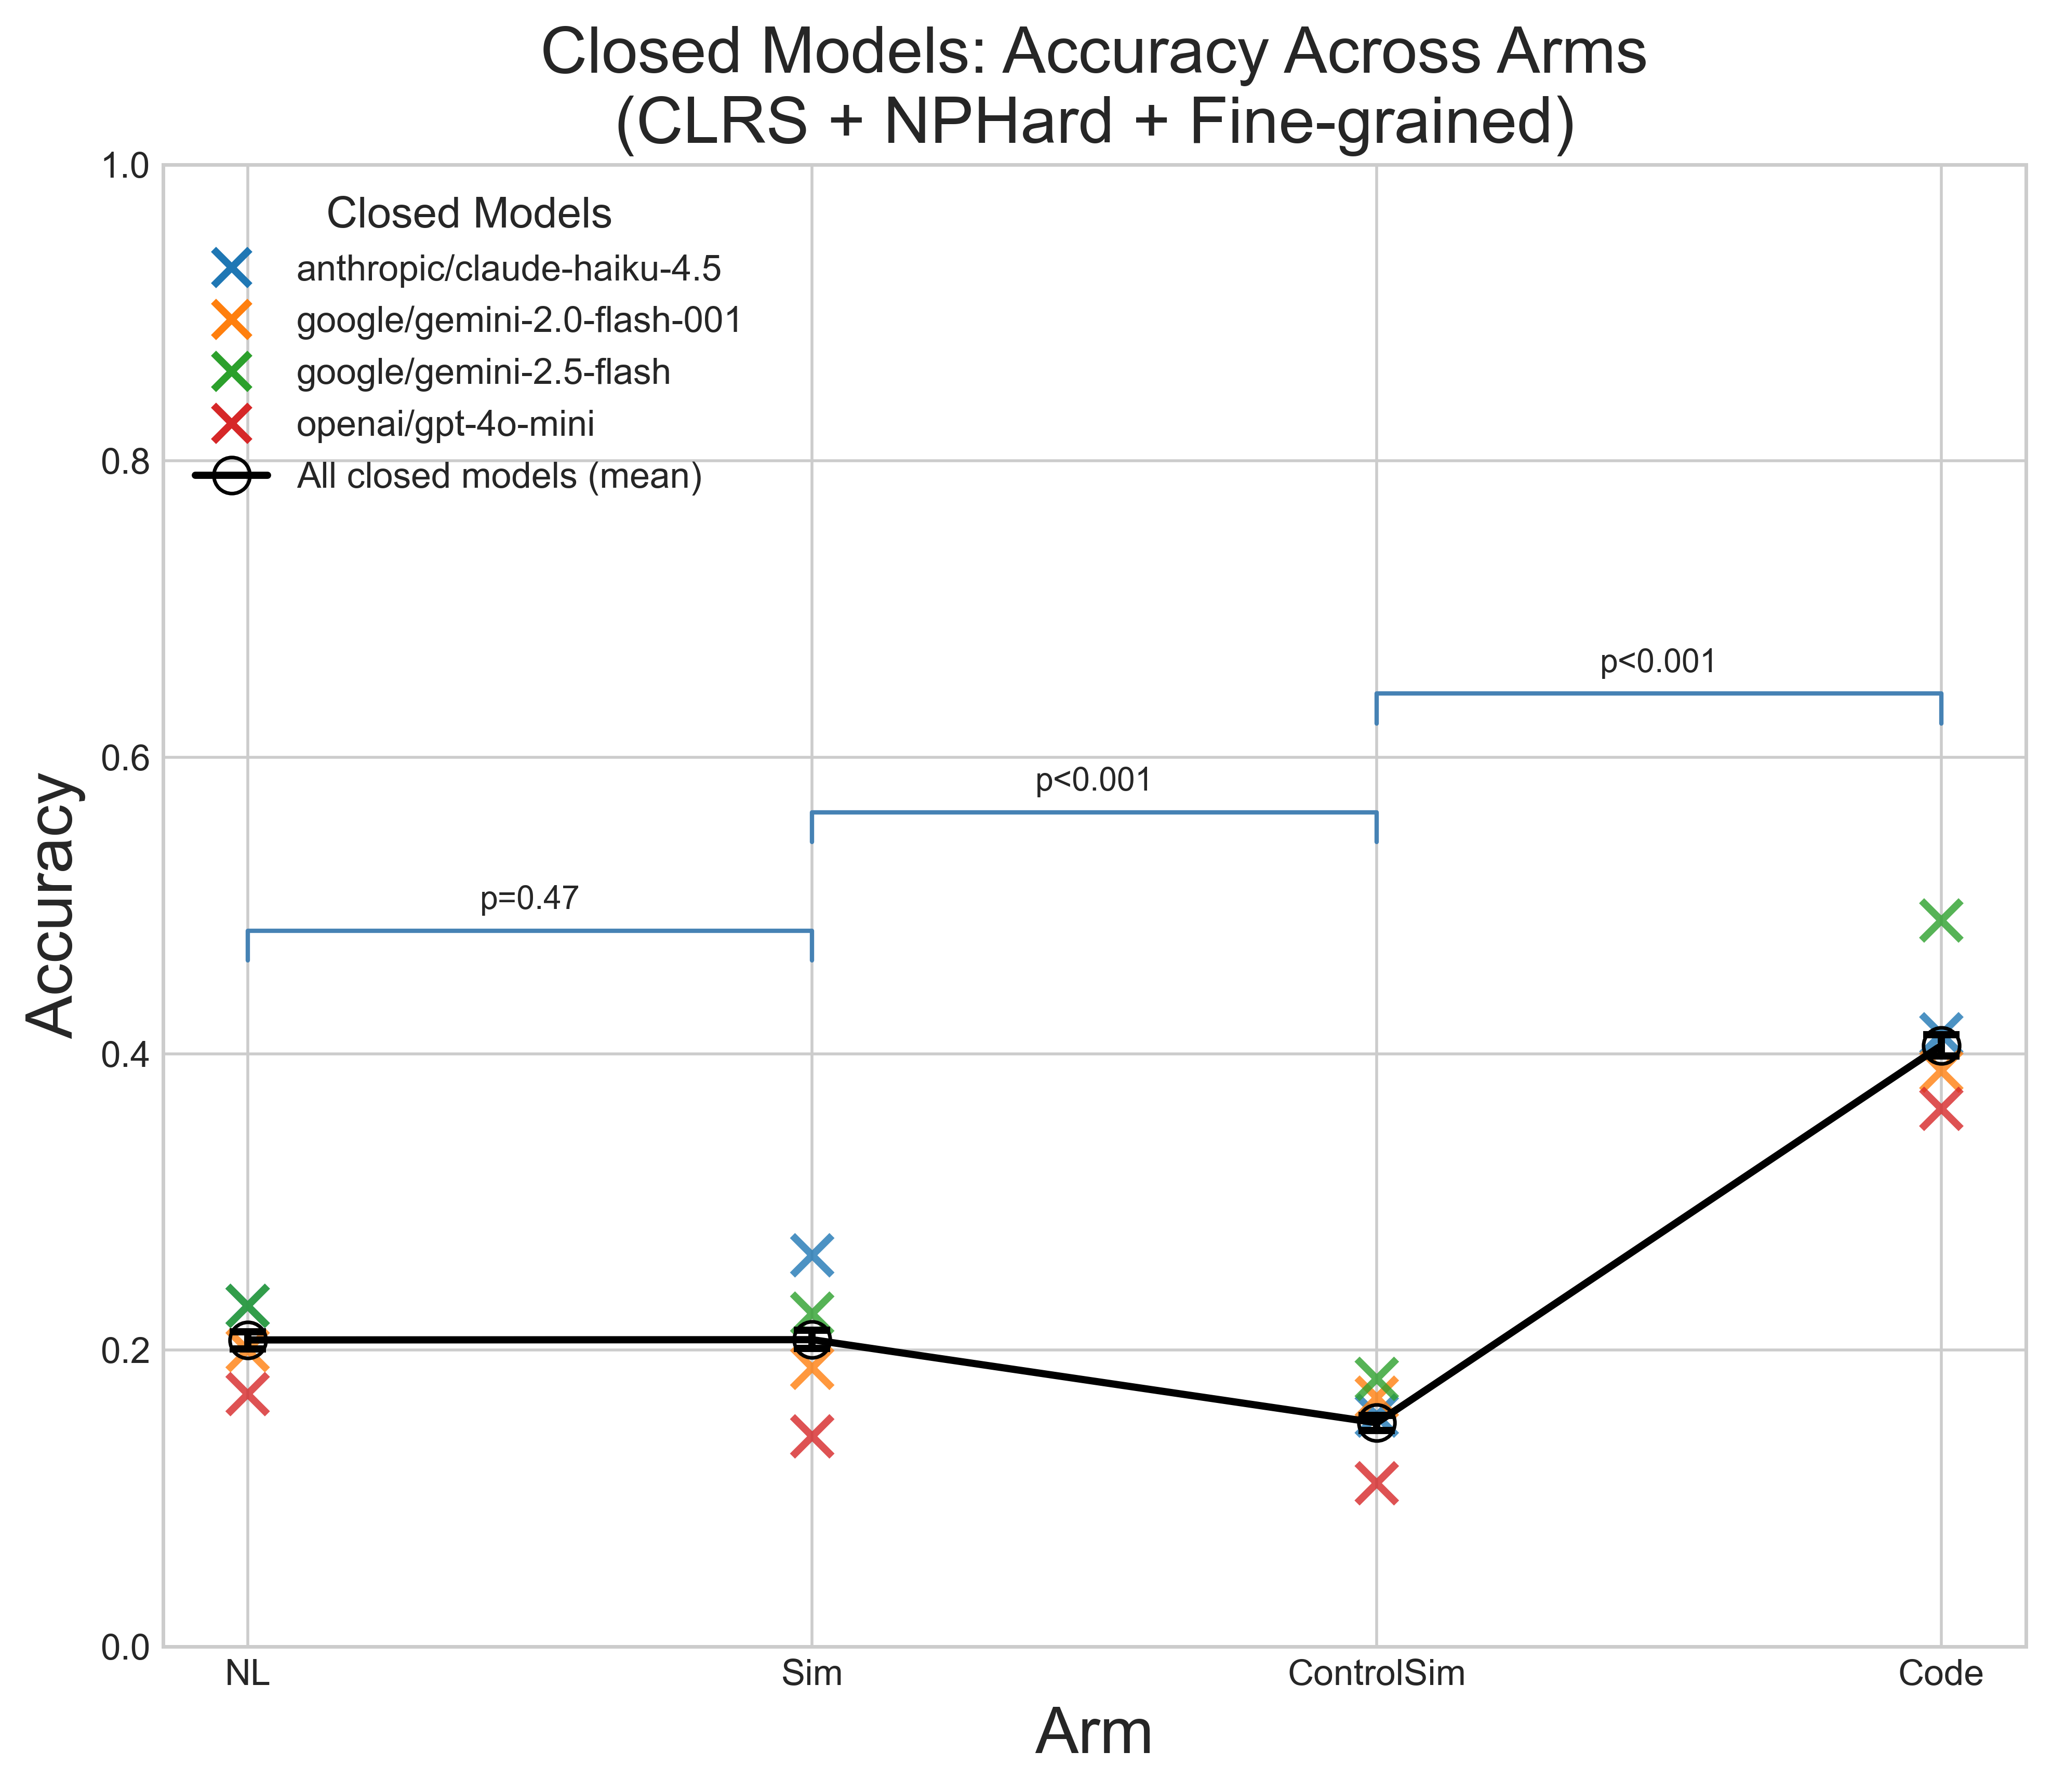

In [7]:
from src.exps_performance.analysis import plot_v_graph_closed

# Change to exps_performance directory for figure saving
exps_perf_dir = Path("..").resolve()
figures_dir = exps_perf_dir / "figures"
figures_dir.mkdir(exist_ok=True)

original_cwd = os.getcwd()
os.chdir(exps_perf_dir)

try:
    print("Generating figure with filtered models (no GSM8K)...")
    plot_v_graph_closed(df_filtered)
    print(f"\nFigure saved to: {figures_dir}/line_closed.png")
finally:
    os.chdir(original_cwd)

## Summary Statistics

In [8]:
print("=" * 70)
print("FINAL SUMMARY - NO GSM8K ANALYSIS")
print("=" * 70)

print("\n1. GSM8K Filtering:")
print(f"   - GSM8K records removed: {gsm8k_count:,}")
print(f"   - Records remaining: {len(df):,}")

print("\n2. JSON Error Filtering (50% threshold):")
print(f"   - Models kept: {len(good_models)}")
print(f"   - Models excluded: {len(bad_models)}")

print("\n3. Final Dataset:")
print(f"   - Total records: {len(df_filtered):,}")
print(f"   - Unique models: {df_filtered['model'].nunique()}")
print(f"   - Unique task kinds: {df_filtered['kind'].nunique()}")

print("\n4. Task Categories Included:")
CLRS_KINDS = {
    "activity_selector",
    "articulation_points",
    "bellman_ford",
    "bfs",
    "binary_search",
    "bridges",
    "bubble_sort",
    "dag_shortest_paths",
    "dfs",
    "dijkstra",
    "find_maximum_subarray_kadane",
    "floyd_warshall",
    "graham_scan",
    "heapsort",
    "insertion_sort",
    "jarvis_march",
    "kmp_matcher",
    "lcs_length",
    "matrix_chain_order",
    "minimum",
    "mst_kruskal",
    "mst_prim",
    "naive_string_matcher",
    "optimal_bst",
    "quickselect",
    "quicksort",
    "segments_intersect",
    "strongly_connected_components",
    "task_scheduling",
    "topological_sort",
}
NPHARD_KINDS = {"edp", "gcp", "ksp", "spp", "tsp"}
FG_KINDS = {"add", "sub", "mul", "lcs", "rod", "knap", "ilp_assign", "ilp_prod", "ilp_partition"}

kinds_in_data = set(df_filtered["kind"].unique())
print(f"   - CLRS tasks: {len(kinds_in_data & CLRS_KINDS)}")
print(f"   - NPHard tasks: {len(kinds_in_data & NPHARD_KINDS)}")
print(f"   - Fine-grained tasks: {len(kinds_in_data & FG_KINDS)}")
print(f"   - GSM8K tasks: {len(kinds_in_data & {'gsm8k'})} (should be 0)")

FINAL SUMMARY - NO GSM8K ANALYSIS

1. GSM8K Filtering:
   - GSM8K records removed: 4,500
   - Records remaining: 41,930

2. JSON Error Filtering (50% threshold):
   - Models kept: 10
   - Models excluded: 0

3. Final Dataset:
   - Total records: 41,930
   - Unique models: 10
   - Unique task kinds: 48

4. Task Categories Included:
   - CLRS tasks: 30
   - NPHard tasks: 5
   - Fine-grained tasks: 9
   - GSM8K tasks: 0 (should be 0)


In [9]:
# Per-model accuracy summary (no GSM8K)
print("\nPer-Model Accuracy (No GSM8K):")
print("-" * 70)

summary = df_filtered.groupby("model")[["code_correct", "nl_correct", "sim_correct"]].mean().round(3)
summary = summary.sort_values("code_correct", ascending=False)
print(summary.to_string())


Per-Model Accuracy (No GSM8K):
----------------------------------------------------------------------
                                    code_correct  nl_correct  sim_correct
model                                                                    
google/gemini-2.5-flash                    0.456       0.242        0.235
mistralai/codestral-2508                   0.408       0.195        0.223
anthropic/claude-haiku-4.5                 0.388       0.243        0.290
google/gemini-2.0-flash-001                0.365       0.233        0.223
openai/gpt-4o-mini                         0.352       0.191        0.167
mistralai/ministral-14b-2512               0.343       0.163        0.156
mistralai/mixtral-8x22b-instruct           0.341       0.196        0.197
mistralai/mistral-large-2411               0.175       0.000        0.191
meta-llama/llama-3.1-405b-instruct         0.139       0.125        0.155
qwen/qwen-2.5-coder-32b-instruct           0.084       0.090        0.116


## Claude Haiku 4.5 Seed 1 Analysis

Detailed analysis of Claude Haiku 4.5 performance on algorithmic tasks (no GSM8K).

In [10]:
# Filter to Claude Haiku 4.5 only
df_haiku = df_filtered[df_filtered["model"] == "anthropic/claude-haiku-4.5"].copy()

print("=" * 70)
print("CLAUDE HAIKU 4.5 ANALYSIS (No GSM8K)")
print("=" * 70)

print(f"\nTotal records: {len(df_haiku):,}")
print(f"Unique task kinds: {df_haiku['kind'].nunique()}")

# Overall accuracy per arm
print("\n" + "-" * 50)
print("Overall Accuracy by Arm:")
print("-" * 50)
for arm in ["code_correct", "nl_correct", "sim_correct"]:
    acc = df_haiku[arm].mean()
    print(f"  {arm.replace('_correct', '').upper():>6}: {acc:.3f} ({acc * 100:.1f}%)")

# Per-task-kind accuracy (top 15 by sample count)
print("\n" + "-" * 50)
print("Accuracy by Task Kind (Top 15 by sample size):")
print("-" * 50)

kind_stats = df_haiku.groupby("kind").agg({"code_correct": ["mean", "count"], "nl_correct": "mean", "sim_correct": "mean"}).round(3)
kind_stats.columns = ["code_acc", "n_samples", "nl_acc", "sim_acc"]
kind_stats = kind_stats.sort_values("n_samples", ascending=False).head(15)
print(kind_stats.to_string())

CLAUDE HAIKU 4.5 ANALYSIS (No GSM8K)

Total records: 6,580
Unique task kinds: 48

--------------------------------------------------
Overall Accuracy by Arm:
--------------------------------------------------
    CODE: 0.388 (38.8%)
      NL: 0.243 (24.3%)
     SIM: 0.290 (29.0%)

--------------------------------------------------
Accuracy by Task Kind (Top 15 by sample size):
--------------------------------------------------
                    code_acc  n_samples  nl_acc  sim_acc
kind                                                    
edp                    0.750        240   0.533    0.667
knap                   0.996        240   0.308    0.392
ksp                    0.692        240   0.058    0.092
lcs                    0.771        240   0.433    0.642
ilp_prod               0.829        240   0.050    0.021
ilp_partition          0.925        240   0.333    0.400
ilp_assign             0.992        240   0.042    0.038
gcp                    0.033        240   0.692    0.379

In [11]:
# Accuracy by task category for Claude Haiku 4.5
def categorize_task(kind):
    """Categorize task by type."""
    CLRS = {
        "activity_selector",
        "articulation_points",
        "bellman_ford",
        "bfs",
        "binary_search",
        "bridges",
        "bubble_sort",
        "dag_shortest_paths",
        "dfs",
        "dijkstra",
        "find_maximum_subarray_kadane",
        "floyd_warshall",
        "graham_scan",
        "heapsort",
        "insertion_sort",
        "jarvis_march",
        "kmp_matcher",
        "lcs_length",
        "matrix_chain_order",
        "minimum",
        "mst_kruskal",
        "mst_prim",
        "naive_string_matcher",
        "optimal_bst",
        "quickselect",
        "quicksort",
        "segments_intersect",
        "strongly_connected_components",
        "task_scheduling",
        "topological_sort",
    }
    NPHARD = {"edp", "gcp", "ksp", "spp", "tsp", "edp_d", "gcp_d", "ksp_d", "msp", "tsp_d"}
    FG = {"add", "sub", "mul", "lcs", "rod", "knap", "ilp_assign", "ilp_prod", "ilp_partition"}

    if kind in CLRS:
        return "CLRS"
    elif kind in NPHARD:
        return "NPHard"
    elif kind in FG:
        return "Fine-grained"
    else:
        return "Other"


df_haiku["category"] = df_haiku["kind"].apply(categorize_task)

print("\n" + "-" * 50)
print("Claude Haiku 4.5 Accuracy by Task Category:")
print("-" * 50)

cat_stats = df_haiku.groupby("category").agg({"code_correct": ["mean", "count"], "nl_correct": "mean", "sim_correct": "mean"}).round(3)
cat_stats.columns = ["code_acc", "n_samples", "nl_acc", "sim_acc"]
cat_stats = cat_stats.sort_values("n_samples", ascending=False)
print(cat_stats.to_string())

# Visual comparison
print("\n" + "-" * 50)
print("Code Accuracy Comparison by Category:")
print("-" * 50)
for cat in cat_stats.index:
    acc = cat_stats.loc[cat, "code_acc"]
    n = int(cat_stats.loc[cat, "n_samples"])
    bar = "█" * int(acc * 40)
    print(f"  {cat:12s} | {bar:40s} {acc:.1%} (n={n})")


--------------------------------------------------
Claude Haiku 4.5 Accuracy by Task Category:
--------------------------------------------------
              code_acc  n_samples  nl_acc  sim_acc
category                                          
CLRS             0.120       2500   0.125    0.143
Fine-grained     0.755       2160   0.261    0.332
NPHard           0.289       1740   0.346    0.376
Other            0.667        180   0.667    1.000

--------------------------------------------------
Code Accuracy Comparison by Category:
--------------------------------------------------
  CLRS         | ████                                     12.0% (n=2500)
  Fine-grained | ██████████████████████████████           75.5% (n=2160)
  NPHard       | ███████████                              28.9% (n=1740)
  Other        | ██████████████████████████               66.7% (n=180)
